# Extended Analysis: AI Framing & Agency Shift in Outage Coverage

1. **Extract & filter**: AI-related sentences from Guardian outage articles
2. **Extract SVO triples**: who does what to whom (handling passive voice)
3. **Classify actors/patients**: classify into broad categories
4. **Plot the agency shift**: how framing changed from pre-AI to post-AI era
5. **Detect narrative devices**: metaphor, technical explanation, attribution


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import spacy, re, math, warnings, torch

sns.set_style("whitegrid")
nlp = spacy.load("en_core_web_sm")

# Load data
df_all = pd.read_csv("merged_relevant_articles.csv")
df_all["pub_date"] = pd.to_datetime(df_all["pub_date"], utc=True, errors="coerce")

df_gd = df_all[(df_all["source"] == "guardian") & (df_all["has_full_text"] == True)].copy()
for col in ["text_for_analysis", "full_text", "text"]:
    if col in df_gd.columns:
        df_gd["text_for_analysis"] = df_gd[col]
        break
df_gd = df_gd.dropna(subset=["text_for_analysis"]).reset_index(drop=True)

print(f"Loaded {len(df_gd)} articles")
print(df_gd.groupby(["era", "event"]).size())


Loaded 269 articles
era      event            
post_ai  aws_2025              28
         azure_2025             2
         crowdstrike_2024      54
         google_cloud_2025     47
pre_ai   aws_2021               1
         facebook_2021        114
         fastly_2021           18
         google_2020            5
dtype: int64


---
## Extract AI-Related Sentences

Keyword matching + POS-validated standalone "AI" detection.


In [2]:
# Extract AI-related sentences
AI_KEYWORDS = [
    "artificial intelligence", "machine learning", "deep learning",
    "neural network", "large language model", "generative ai",
    "chatgpt", "openai", "copilot", "gemini", "llm", "llms",
    "algorithm", "algorithmic", "automated", "automation",
    "cloud computing", "cybersecurity", "digital infrastructure",
    "software update", "single point of failure", "cascading failure",
]

ai_rows = []
for idx, row in df_gd.iterrows():
    doc = nlp(str(row["text_for_analysis"])[:100000])
    for sent in doc.sents:
        text = sent.text.strip()
        if len(text) < 20:
            continue
        lower = text.lower()

        # Keyword match
        matched = [kw for kw in AI_KEYWORDS if kw in lower]

        # POS-validated "AI" — must be NOUN or PROPN
        if not matched:
            for tok in sent:
                if tok.text == "AI" and tok.pos_ in ("NOUN", "PROPN"):
                    matched.append("AI")
                    break

        if matched:
            ai_rows.append({
                "article_idx": idx, "era": row["era"], "event": row["event"],
                "title": row["title"], "sentence": text,
                "matched_terms": "|".join(matched[:3]),
            })

df_ai = pd.DataFrame(ai_rows)
print(f"Extracted {len(df_ai)} AI-related sentences from {df_ai['article_idx'].nunique()} articles")
print(df_ai.groupby("era").size())


Extracted 383 AI-related sentences from 98 articles
era
post_ai    296
pre_ai      87
dtype: int64


---
## Extract SVO Triples (Handling Passive Voice)

News reporting frequently uses passive constructions ("services were disrupted", "users were affected"). We detect passive voice via spaCy's `nsubjpass` dependency label and reconstruct the true actor from `agent` phrases (e.g., "by CrowdStrike").


In [3]:
# SVO Extraction with passive voice handling
def get_noun_phrase(token):
    """Noun phrase via noun_chunks, fallback to safe subtree."""
    for chunk in token.doc.noun_chunks:
        if token.i >= chunk.start and token.i < chunk.end:
            return chunk.text.strip()
    safe = {"det", "amod", "compound", "poss", "nummod"}
    pts = sorted([token] + [c for c in token.children if c.dep_ in safe], key=lambda t: t.i)[:8]
    return " ".join(t.text for t in pts).strip()


def extract_svo(doc):
    """Extract SVO triples. For passive voice, recover the real agent from 'by' phrases."""
    triples = []
    for sent in doc.sents:
        for tok in sent:
            if tok.dep_ != "ROOT" or tok.pos_ != "VERB":
                continue
            subjects = [c for c in tok.children if c.dep_ in ("nsubj", "nsubjpass")]
            objects = [c for c in tok.children if c.dep_ in ("dobj", "attr")]
            if not objects:
                for c in tok.children:
                    if c.dep_ == "prep":
                        objects.extend(gc for gc in c.children if gc.dep_ == "pobj")

            is_passive = any(c.dep_ == "nsubjpass" for c in subjects)

            # Recover agent from "by ..." phrase in passive constructions, AI assisted
            agent_phrase = None
            if is_passive:
                for c in tok.children:
                    if c.dep_ == "agent":
                        for gc in c.children:
                            if gc.dep_ == "pobj":
                                agent_phrase = get_noun_phrase(gc)
                                break

            # Build verb phrase with auxiliaries
            aux = sorted([(c.i, c.text) for c in tok.children if c.dep_ in ("aux", "auxpass", "neg")])
            verb_text = " ".join([t[1] for t in aux] + [tok.lemma_]) if aux else tok.lemma_

            for subj in subjects:
                subj_phrase = get_noun_phrase(subj)

                if is_passive:
                    # Passive: grammatical subject is actually the patient
                    patient = subj_phrase
                    actor = agent_phrase if agent_phrase else "[implicit]"
                    voice = "passive"
                else:
                    actor = subj_phrase
                    patient = None
                    voice = "active"

                if objects:
                    for obj in objects:
                        obj_phrase = get_noun_phrase(obj)
                        triples.append({
                            "actor": actor if voice == "active" else actor,
                            "verb": verb_text, "verb_lemma": tok.lemma_,
                            "patient": obj_phrase if voice == "active" else patient,
                            "voice": voice,
                            "sentence": sent.text.strip(),
                        })
                else:
                    triples.append({
                        "actor": actor,
                        "verb": verb_text, "verb_lemma": tok.lemma_,
                        "patient": patient if patient else "[none]",
                        "voice": voice,
                        "sentence": sent.text.strip(),
                    })
    return triples

all_triples = []
for _, row in df_ai.iterrows():
    doc = nlp(row["sentence"])
    triples = extract_svo(doc)
    for t in triples:
        t["era"] = row["era"]
        t["event"] = row["event"]
        t["article_idx"] = row["article_idx"]
    all_triples.extend(triples)

df_svo = pd.DataFrame(all_triples)
print(f"Extracted {len(df_svo)} SVO triples")
print(f"By era: {df_svo.groupby('era').size().to_dict()}")
print(f"Voice: {df_svo['voice'].value_counts().to_dict()}")


Extracting SVO triples...
Extracted 329 SVO triples
By era: {'post_ai': 255, 'pre_ai': 74}
Voice: {'active': 299, 'passive': 30}


---
## Classify Actors & Patients via Zero-Shot

We classify every unique actor/patient phrase into 6 broad categories using gemini 


In [7]:
# Entity classification
import os, json, time
import google.generativeai as genai

GEMINI_MODEL = "gemini-2.5-flash"
BATCH_SIZE = 50

api_key = os.environ.get("GEMINI_API_KEY", "")
genai.configure(api_key=api_key)
model = genai.GenerativeModel(GEMINI_MODEL)
print(f"Using {GEMINI_MODEL}")

CATEGORIES = ["company", "ai_system", "tech_system", "user_public", "government", "person"]
SKIP = {"it", "its", "they", "them", "he", "she", "this", "that", "which", "who",
        "what", "i", "we", "you", "me", "us", "[none]", "[implicit]"}


def classify_mentions_batch(mentions, model):
    """Send a batch of mentions to Gemini, return {mention: category} dict."""
    prompt = json.dumps({
        "task": (
            "Classify each phrase into exactly one category. "
            "Return ONLY a JSON list of objects with keys: mention, category."
        ),
        "categories": {
            "company": "A named technology company or corporate brand (e.g., Facebook, CrowdStrike, Amazon, Google)",
            "ai_system": "An AI model, algorithm, or AI-powered system (e.g., AI, ChatGPT, the algorithm, the model)",
            "tech_system": "Technology infrastructure — servers, software, platforms, updates, networks",
            "user_public": "End users, customers, the general public, passengers, patients",
            "government": "Government bodies, regulators, lawmakers, Congress",
            "person": "A named individual — CEO, engineer, spokesperson, politician",
        },
        "mentions": mentions,
    }, ensure_ascii=False)

    try:
        resp = model.generate_content(prompt)
        text = resp.text.strip()
        # Strip markdown fences if present
        text = text.removeprefix("```json").removeprefix("```").removesuffix("```").strip()
        parsed = json.loads(text)
        result = {}
        for item in parsed:
            m = item.get("mention", "")
            c = item.get("category", "other")
            result[m] = c if c in CATEGORIES else "other"
        return result
    except Exception as e:
        print(f"  Batch failed: {e}")
        return {}


actors = df_svo["actor"].dropna().unique().tolist()
patients = df_svo["patient"].dropna().unique().tolist()
all_mentions = list(set(actors + patients))

# Pre-filter pronouns and noise
mention_map = {}
to_classify = []
for m in all_mentions:
    if m.lower().strip() in SKIP or len(m.strip()) <= 1:
        mention_map[m] = "pronoun"
    else:
        to_classify.append(m)

print(f"{len(to_classify)} unique mentions to classify, {len(mention_map)} skipped as pronouns")

# Batch classify via Gemini
batches = [to_classify[i:i+BATCH_SIZE] for i in range(0, len(to_classify), BATCH_SIZE)]
for i, batch in enumerate(batches):
    result = classify_mentions_batch(batch, model)
    for m in batch:
        mention_map[m] = result.get(m, "other")
    print(f"  Batch {i+1}/{len(batches)}: {len(result)}/{len(batch)} classified")
    if i < len(batches) - 1:
        time.sleep(1)

df_svo["actor_category"] = df_svo["actor"].map(mention_map).fillna("other")
df_svo["patient_category"] = df_svo["patient"].map(mention_map).fillna("other")

print("\nActor distribution by era:")
print((pd.crosstab(df_svo["era"], df_svo["actor_category"], normalize="index") * 100).round(1))
print("\nPatient distribution by era:")
print((pd.crosstab(df_svo["era"], df_svo["patient_category"], normalize="index") * 100).round(1))


Using gemini-2.5-flash
381 unique mentions to classify, 17 skipped as pronouns
  Batch 1/8: 50/50 classified
  Batch 2/8: 50/50 classified
  Batch 3/8: 50/50 classified
  Batch 4/8: 50/50 classified
  Batch 5/8: 50/50 classified
  Batch 6/8: 50/50 classified
  Batch 7/8: 50/50 classified
  Batch 8/8: 31/31 classified

Actor distribution by era:
actor_category  ai_system  company  government  person  pronoun  tech_system  \
era                                                                            
post_ai               4.7     31.0         3.5    16.5     24.3         10.2   
pre_ai                5.4     20.3        12.2    23.0     27.0          8.1   

actor_category  user_public  
era                          
post_ai                 9.8  
pre_ai                  4.1  

Patient distribution by era:
patient_category  ai_system  company  government  person  pronoun  \
era                                                                 
post_ai                 5.1     22.0        

In [10]:
# Manual validation: inspect LLM entity classifications

print("Sample classifications by category")

for cat in sorted(df_svo["actor_category"].unique()):
    examples = df_svo[df_svo["actor_category"] == cat]["actor"].drop_duplicates().head(10).tolist()
    print(f"\n  {cat:15s} ({len(examples)} shown): {', '.join(examples)}")

# Full mention → category mapping for manual review
df_mentions = (
    pd.DataFrame(list(mention_map.items()), columns=["mention", "category"])
    .sort_values("category")
    .reset_index(drop=True)
)

print(f"\n{'=' * 80}")
print(f"Full mapping: {len(df_mentions)} mentions across {df_mentions['category'].nunique()} categories")
print("=" * 80)
display(df_mentions.groupby("category")["mention"].apply(list).to_frame())

other_mentions = df_mentions[df_mentions["category"] == "other"]
if not other_mentions.empty:
    print(f"\n{len(other_mentions)} mentions classified as 'other' (review these):")
    for _, row in other_mentions.iterrows():
        print(f"    '{row['mention']}'")

Sample classifications by category

  ai_system       (10 shown): the company’s algorithms, Divisive algorithm, The company’s algorithmic moderation software, machine learning, algorithms, The AI boom’s incomprehensibly vast numbers, Large language models, AI’s physical imprint, AI, AI’s presence

  company         (10 shown): The startup, Facebook’s integrity team, the company, its quest, growth, Facebook, social media companies, Twitter, The internal documents, the WSJ

  government      (10 shown): The legislation, The 2018, an investigation, the proposed law, The ISD, The bill, The information commissioner, The draft bill, Britain, Cybersecurity regulations

  person          (10 shown): Imran Ahmed, Ahmed, Haugen, Douglas, Zuckerberg, Evan Greer, Rosie Sharpe, Seth Meyers, Frances Haugen, Clegg

  pronoun         (10 shown): She, she, we, [implicit], it, We, he, It, They, That

  tech_system     (10 shown): your main research tools, the Facebook outage, Much, The internet outage, 

,mention
category,
ai_system,"[AI’s physical imprint, chatbots, AI, Generati..."
company,"[CrowdStrike, Stockholm, Mission Impossible, a..."
government,"[the federal government, A government spokespe..."
person,"[@Growing_Daniel, Humphrey, Jassy, Blythe Craw..."
pronoun,"[They, it, [none], That, It, you, we, them, sh..."
tech_system,"[its weight, The initial disruption, its new, ..."
user_public,"[a character, MIT researchers, All, users, sci..."


---
## Agency Shift


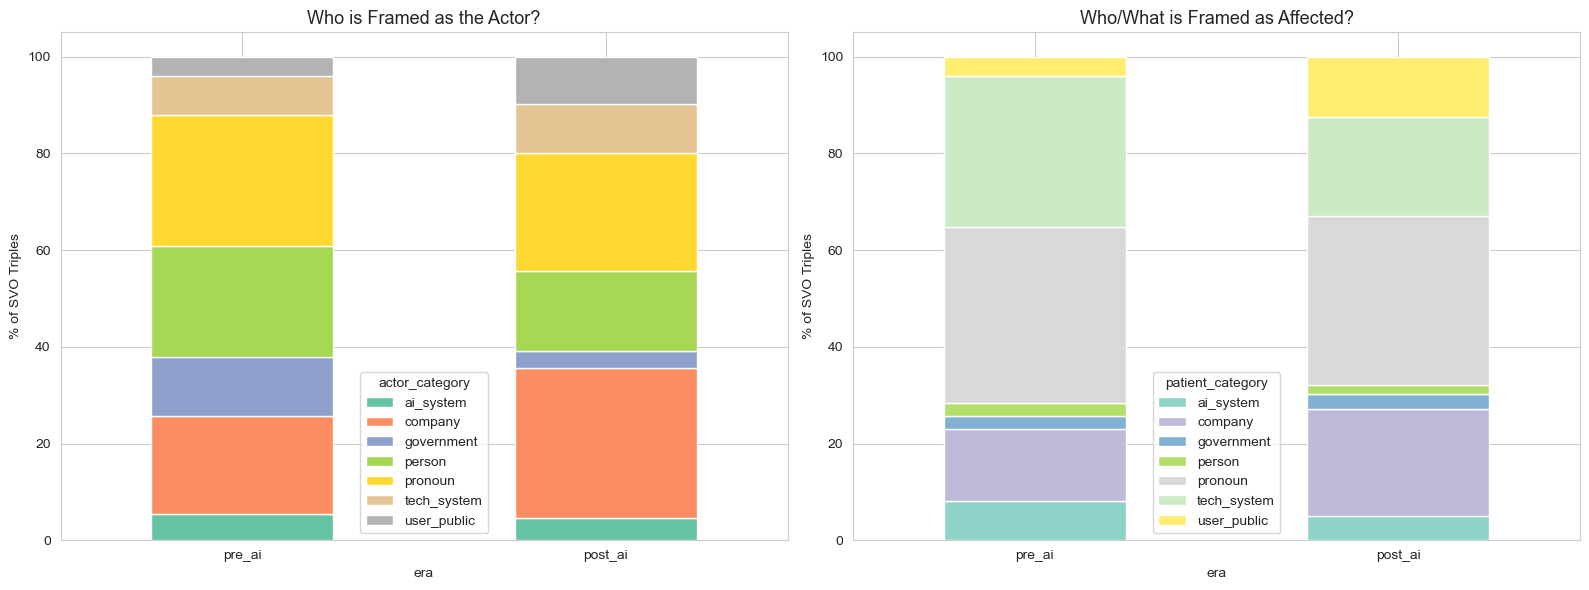

Agency among Company, AI, Tech:
actor_category  ai_system  company  tech_system
era                                            
pre_ai               16.0     60.0         24.0
post_ai              10.3     67.5         22.2


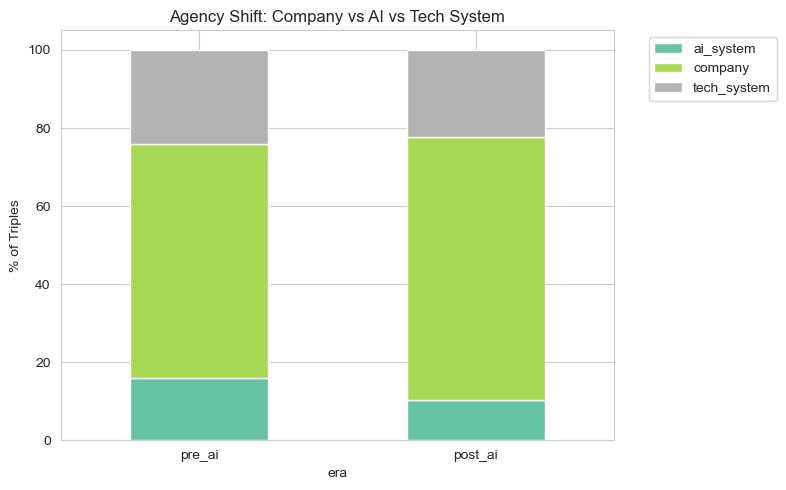


Passive voice rate:
era
post_ai    9.4
pre_ai     8.1
Name: voice, dtype: float64

Verb frames when Tech/AI is the actor:
verb_frame  communicative  impact  mechanical
era                                          
pre_ai               50.0     0.0        50.0
post_ai               0.0   100.0         0.0


In [11]:
# Agency shift visualization

# Verb frame dictionary (deterministic)
VERB_FRAMES = {
    "cognitive": {"decide", "learn", "think", "predict", "hallucinate", "analyze",
                  "recognize", "understand", "generate", "train", "classify", "detect", "automate"},
    "mechanical": {"crash", "fail", "break", "overload", "malfunction", "disconnect",
                   "freeze", "reboot", "degrade", "corrupt"},
    "impact": {"disrupt", "affect", "strand", "halt", "cripple", "damage", "cause",
               "impact", "prevent", "delay", "block", "ground", "leave"},
    "communicative": {"say", "tell", "state", "warn", "announce", "confirm", "report",
                      "explain", "reveal", "argue", "claim", "deny"},
}
lemma_to_frame = {}
for frame, verbs in VERB_FRAMES.items():
    for v in verbs:
        lemma_to_frame[v] = frame

df_svo["verb_frame"] = df_svo["verb_lemma"].str.lower().map(lemma_to_frame).fillna("other")



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

actor_dist = pd.crosstab(df_svo["era"], df_svo["actor_category"], normalize="index") * 100
actor_dist.reindex(["pre_ai", "post_ai"]).plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Who is Framed as the Actor?", fontsize=13)
axes[0].set_ylabel("% of SVO Triples")
axes[0].tick_params(axis='x', rotation=0)

patient_dist = pd.crosstab(df_svo["era"], df_svo["patient_category"], normalize="index") * 100
patient_dist.reindex(["pre_ai", "post_ai"]).plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3")
axes[1].set_title("Who/What is Framed as Affected?", fontsize=13)
axes[1].set_ylabel("% of SVO Triples")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


focus_cats = ["company", "ai_system", "tech_system"]
focus = df_svo[df_svo["actor_category"].isin(focus_cats)]
if not focus.empty:
    sg = pd.crosstab(focus["era"], focus["actor_category"], normalize="index") * 100
    print("Agency among Company, AI, Tech:")
    print(sg.reindex(["pre_ai", "post_ai"]).round(1))

    sg.reindex(["pre_ai", "post_ai"]).plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
    plt.title("Agency Shift: Company vs AI vs Tech System")
    plt.ylabel("% of Triples")
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

#Passive voice rate
passive = df_svo.groupby("era")["voice"].apply(lambda s: (s == "passive").mean() * 100)
print(f"\nPassive voice rate:\n{passive.round(1)}")

#Verb frames for tech actors
tech_actors = df_svo[df_svo["actor_category"].isin(["ai_system", "tech_system"])]
tech_frames = tech_actors[~tech_actors["verb_frame"].isin(["other"])]
if not tech_frames.empty:
    vf = pd.crosstab(tech_frames["era"], tech_frames["verb_frame"], normalize="index") * 100
    print(f"\nVerb frames when Tech/AI is the actor:")
    print(vf.reindex(["pre_ai", "post_ai"]).round(1))

---
## Narrative Devices


Narrative devices by era (% of AI sentences):
        has_metaphor has_technical has_attribution
era                                               
pre_ai         1.15%         3.45%          24.14%
post_ai        0.34%         3.72%          15.54%


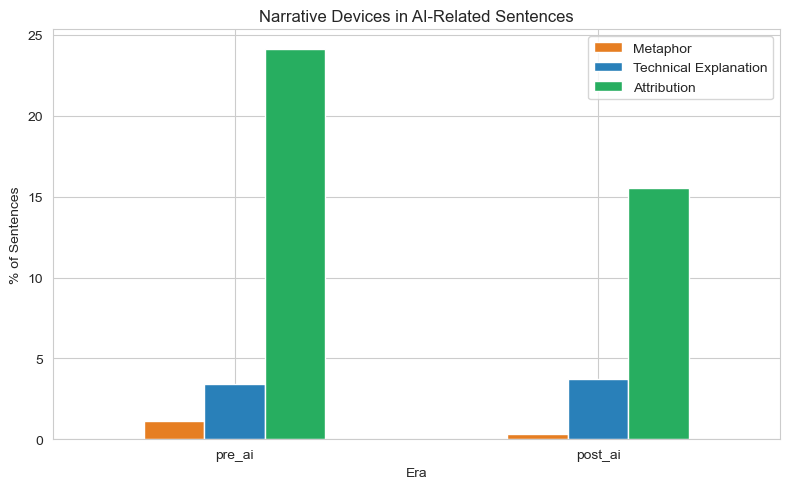

In [9]:
# Narrative devices (deterministic regex)

METAPHOR = [r"\blike a\b", r"\bas if\b", r"\bsimilar to\b", r"\bequivalent of\b",
            r"\banalog(?:y|ous)\b", r"\bin other words\b", r"\bto put it simply\b"]
TECHNICAL = [r"(root cause|post.?mortem|investigation found|technical (details|explanation))",
             r"(what (actually )?happened|how .+ (works|failed))",
             r"(the (bug|error|flaw|issue) (was|involved|stemmed))",
             r"(configuration|deployment|kernel|driver|endpoint|api|dns|bgp|routing)",
             r"(the (update|patch|change) that)"]
ATTRIBUTION = [r"(said|told|according to|spokesperson|statement)",
               r'("[^"]{10,}")',
               r"(expert|analyst|researcher|professor)\s+(said|told|warned)"]

def has_pattern(text, patterns):
    text = str(text).lower()
    return any(re.search(p, text, re.I) for p in patterns)

df_ai["has_metaphor"] = df_ai["sentence"].apply(lambda t: has_pattern(t, METAPHOR))
df_ai["has_technical"] = df_ai["sentence"].apply(lambda t: has_pattern(t, TECHNICAL))
df_ai["has_attribution"] = df_ai["sentence"].apply(lambda t: has_pattern(t, ATTRIBUTION))

print("Narrative devices by era (% of AI sentences):")
summary = df_ai.groupby("era")[["has_metaphor", "has_technical", "has_attribution"]].mean() * 100
print(summary.reindex(["pre_ai", "post_ai"]).round(2).astype(str) + "%")

fig, ax = plt.subplots(figsize=(8, 5))
summary.reindex(["pre_ai", "post_ai"]).plot(kind="bar", ax=ax, color=["#e67e22", "#2980b9", "#27ae60"])
ax.set_title("Narrative Devices in AI-Related Sentences")
ax.set_ylabel("% of Sentences")
ax.set_xlabel("Era")
ax.tick_params(axis='x', rotation=0)
ax.legend(["Metaphor", "Technical Explanation", "Attribution"])
plt.tight_layout()
plt.show()
